# 01 — CartPole Experiments: From Baseline DQN to DDQN + PER + N-step

**Цель:** реализовать и исследовать DQN на **CartPole-v1** с *Experience Replay*; затем пошагово улучшить:
- Базовый **DQN** (uniform replay, ε-greedy)
- **DDQN** (снижает переоценку Q)
- **PER** (Prioritized Experience Replay) и **N-step** returns
- Мягкое обновление таргет-сети (Polyak, τ)

**План работы:**
1. Инициализируем окружение и пайплайн.
2. Запускаем **baseline** (простой DQN) и визуализируем кривые.
3. Добавляем **DDQN**, затем **PER** и **N-step**, сравниваем результаты.
4. Мини-свип гиперпараметров (learning rate, ε-schedule, τ).
5. **Экспортируем лучшую конфигурацию** в `configs/cartpole.yaml` для запуска через скрипт.

**Визуализация:** TensorBoard + простые графики из TB event-файлов.


## Проверка окружения и путей

In [1]:
import base64
import glob
import gymnasium as gym
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import shutil
import subprocess
import sys
import time
import torch
import yaml

from IPython.display import clear_output, display, HTML
from itertools import product
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from tqdm import tqdm

CWD = Path.cwd().resolve()
PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")

print("CWD         =", CWD)
print("PROJECT_ROOT=", PROJECT_ROOT)

CONFIG_BASE = PROJECT_ROOT / "configs" / "cartpole.yaml"
ARTIFACTS = PROJECT_ROOT / "artifacts"
TB_DIR = ARTIFACTS / "tensorboard"
VIDEOS_DIR = ARTIFACTS / "videos"
CHECKPOINTS_DIR = ARTIFACTS / "checkpoints"
for p in [ARTIFACTS, TB_DIR, VIDEOS_DIR, CHECKPOINTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("Gymnasium:", gym.__version__)
print("TensorBoard logs ->", TB_DIR)

CWD         = D:\ML\LS\Deep_learning\Reinforcement_learning\project\notebooks
PROJECT_ROOT= D:\ML\LS\Deep_learning\Reinforcement_learning\project
Python: 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:40:08) [MSC v.1938 64 bit (AMD64)]
Torch: 2.5.1 | CUDA available: True
Gymnasium: 0.29.1
TensorBoard logs -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\tensorboard


## Вспомогательные функции: YAML, запуск тренировки, парсинг TB

In [2]:
def load_yaml(path):
    with open(path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)

def deep_update(d, u):
    for k, v in u.items():
        if isinstance(v, dict) and k in d:
            d[k] = deep_update(d.get(k, {}), v)
        else:
            d[k] = v
    return d

def save_yaml(d, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        yaml.safe_dump(d, f, sort_keys=False, allow_unicode=True)
    return path

def run_training_with_config(tmp_cfg_path):
    """Запустить train/train_cartpole.py как модуль, чтобы корректно работали импорты пакетов."""
    cmd = [sys.executable, "-m", "train.train_cartpole", "--config", str(tmp_cfg_path)]
    print("RUN (cwd=PROJECT_ROOT):", " ".join(map(str, cmd)))
    # ВАЖНО: работаем из корня репозитория, чтобы 'train', 'envs', 'models' были видны как пакеты
    return subprocess.run(cmd, capture_output=False, cwd=PROJECT_ROOT).returncode

def latest_tb_run(tb_dir=TB_DIR):
    ev = sorted(tb_dir.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

def load_tb_scalars(run_dir, tag='train/episode_return'):
    ea = EventAccumulator(str(run_dir))
    ea.Reload()
    scalars = ea.Tags().get('scalars', [])
    if tag not in scalars:
        return pd.DataFrame(columns=['step','value'])
    ev = ea.Scalars(tag)
    return pd.DataFrame({'step':[e.step for e in ev], 'value':[e.value for e in ev]})

def moving_average(x, w=100):
    if len(x) == 0: 
        return np.array([])
    w = min(w, len(x))
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[w:] - c[:-w]) / float(w)

## Baseline DQN (uniform replay, без DDQN, n=1)

In [3]:
base = load_yaml(CONFIG_BASE)

baseline_override = {
    'agent': {'double_dqn': False, 'dueling': False, 'n_step': 1, 'lr': 5e-4, 'tau': 0.005, 'gamma': 0.99},
    'replay': {'type': 'uniform', 'capacity': 50000, 'batch_size': 64, 'warmup_steps': 1000},
    'exploration': {'eps_start': 1.0, 'eps_end': 0.05, 'eps_decay_steps': 20000},
    'logging': {'log_dir': str(ARTIFACTS)},
    'total_steps': 80000, 'eval_every_steps': 10000, 'eval_episodes': 5
}
cfg_baseline = deep_update(base.copy(), baseline_override)
tmp_cfg = PROJECT_ROOT / 'configs' / 'cartpole_tmp_baseline.yaml'
save_yaml(cfg_baseline, tmp_cfg)
print('Saved baseline cfg ->', tmp_cfg)

Saved baseline cfg -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\cartpole_tmp_baseline.yaml


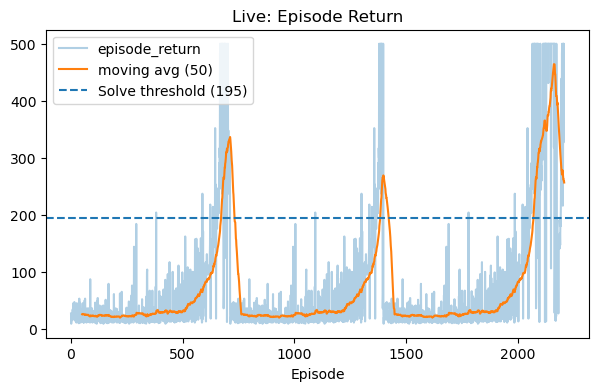

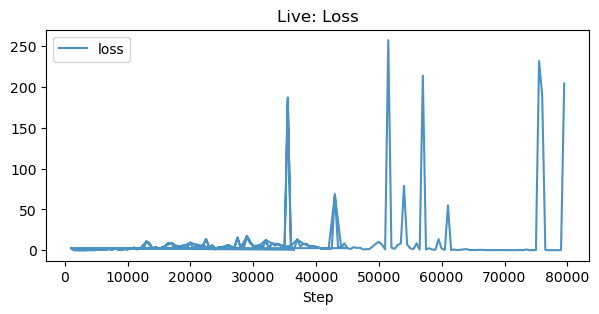

[streaming log] shown lines: 4084
Training CartPole: 100% 79770/80000 [05:55<00:01, 228.09it/s, buf=5e+4, eps=0.050, loss=204.505]
Training CartPole: 100% 79793/80000 [05:55<00:00, 217.76it/s, buf=5e+4, eps=0.050, loss=204.505]
Training CartPole: 100% 79810/80000 [05:56<00:00, 217.76it/s, buf=5e+4, ep=810, eps=0.050, ma100=354.6, ret=500.0]
Training CartPole: 100% 79815/80000 [05:56<00:00, 212.49it/s, buf=5e+4, ep=810, eps=0.050, ma100=354.6, ret=500.0]
Training CartPole: 100% 79837/80000 [05:56<00:00, 203.31it/s, buf=5e+4, ep=810, eps=0.050, ma100=354.6, ret=500.0]
Training CartPole: 100% 79858/80000 [05:56<00:00, 198.03it/s, buf=5e+4, ep=810, eps=0.050, ma100=354.6, ret=500.0]
Training CartPole: 100% 79878/80000 [05:56<00:00, 196.84it/s, buf=5e+4, ep=810, eps=0.050, ma100=354.6, ret=500.0]
Training CartPole: 100% 79901/80000 [05:56<00:00, 206.10it/s, buf=5e+4, ep=810, eps=0.050, ma100=354.6, ret=500.0]
Training CartPole: 100% 79926/80000 [05:56<00:00, 216.78it/s, buf=5e+4, ep=810, ep

In [6]:
# старт процесса с пайпами и объединением stderr -> stdout
cmd = [sys.executable, "-m", "train.train_cartpole", "--config", str(tmp_cfg)]
print("RUN (streaming):", " ".join(map(str, cmd)))
proc = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True
)

# живое чтение лога + обновление графика каждые N секунд
last_refresh = 0
refresh_every = 3.0   # сек
log_lines_shown = 0

try:
    while True:
        line = proc.stdout.readline()
        if line == "" and proc.poll() is not None:
            break
        if line:
            # печатаем потоково прогресс/логи обучения
            print(line, end="")
            log_lines_shown += 1

        # периодически перерисовываем график из TB
        now = time.time()
        if now - last_refresh >= refresh_every:
            last_refresh = now
            run_dir = latest_tb_run()
            if run_dir is not None:
                df_ret  = load_tb_scalars(run_dir, "train/episode_return")
                df_loss = load_tb_scalars(run_dir, "train/loss")
                clear_output(wait=True)
                # верх: эпизодная награда
                plt.figure(figsize=(7,4))
                if len(df_ret):
                    y = df_ret["value"].to_numpy()
                    plt.plot(y, alpha=0.35, label="episode_return")
                    ma = moving_average(y, w=50)
                    if len(ma):
                        plt.plot(range(50, 50+len(ma)), ma, label="moving avg (50)")
                plt.axhline(195, ls="--", label="Solve threshold (195)")
                plt.title("Live: Episode Return")
                plt.xlabel("Episode"); plt.legend(); plt.show()

                # низ: лосс
                plt.figure(figsize=(7,3))
                if len(df_loss):
                    x = df_loss["step"].to_numpy()
                    y = df_loss["value"].to_numpy()
                    plt.plot(x, y, alpha=0.8, label="loss")
                plt.title("Live: Loss")
                plt.xlabel("Step"); plt.legend(); plt.show()
                print(f"[streaming log] shown lines: {log_lines_shown}")
            else:
                print("Waiting for TensorBoard logs…")
        time.sleep(0.05)
finally:
    if proc.poll() is None:
        proc.terminate()
        proc.wait()

print("Training finished.")

Latest TB run: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\tensorboard
=== Summary (CartPole) ===
                episodes_total: 2208
          final_episode_return: 500.0
                  mean_last100: 354.65
          final_moving_avg_100: 354.65
           best_moving_avg_100: 405.87
 episode_to_solve_(ma100>=195): 688


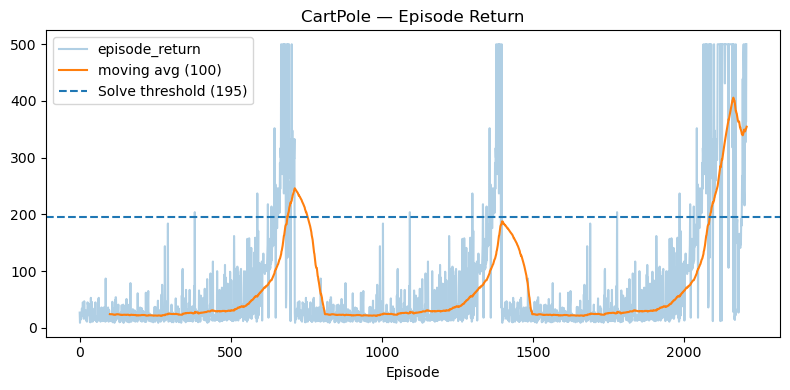

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\plots\cartpole_episode_return.png


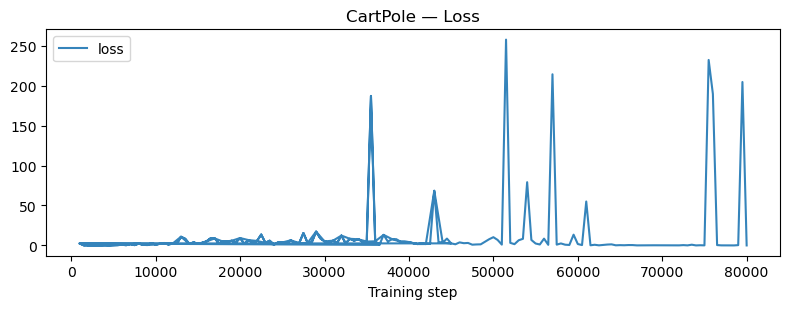

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\plots\cartpole_loss.png
Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\metrics_cartpole.json


In [7]:
# читаем последний запуск из TensorBoard
run_dir = latest_tb_run()
print("Latest TB run:", run_dir)

df_ret  = load_tb_scalars(run_dir, "train/episode_return")
df_loss = load_tb_scalars(run_dir, "train/loss")

# базовые метрики по CartPole
w = 100
ret = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
ma  = moving_average(ret, w=w)

episodes_total   = int(len(ret))
final_return     = float(ret[-1]) if len(ret) else float("nan")
mean_last100     = float(np.mean(ret[-w:])) if len(ret) >= 1 else float("nan")
final_ma100      = float(ma[-1]) if len(ma) else float("nan")
best_ma100       = float(np.max(ma)) if len(ma) else float("nan")
solve_threshold  = 195.0
solve_ep         = None
if len(ma):
    idx = np.argmax(ma >= solve_threshold)  # первое достижение порога
    if ma[idx] >= solve_threshold:
        solve_ep = int(idx + w)  # номер эпизода, где moving avg впервые >= 195

summary = {
    "episodes_total": episodes_total,
    "final_episode_return": round(final_return, 2),
    "mean_last100": round(mean_last100, 2),
    "final_moving_avg_100": round(final_ma100, 2),
    "best_moving_avg_100": round(best_ma100, 2),
    "episode_to_solve_(ma100>=195)": solve_ep,
}
print("=== Summary (CartPole) ===")
for k, v in summary.items():
    print(f"{k:>30}: {v}")

# графики + сохранение в artifacts/plots
PLOTS_DIR = PROJECT_ROOT / "artifacts" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Episode Return
plt.figure(figsize=(8,4))
if len(ret):
    plt.plot(ret, alpha=0.35, label="episode_return")
    if len(ma):
        plt.plot(np.arange(len(ma)) + w, ma, label=f"moving avg ({w})")
plt.axhline(solve_threshold, ls="--", label="Solve threshold (195)")
plt.title("CartPole — Episode Return")
plt.xlabel("Episode"); plt.legend(); plt.tight_layout()
ep_plot_path = PLOTS_DIR / "cartpole_episode_return.png"
plt.savefig(ep_plot_path, dpi=150)
plt.show()
print("Saved:", ep_plot_path)

# Loss (по шагам оптимизации)
plt.figure(figsize=(8,3.2))
if len(df_loss):
    x = df_loss["step"].to_numpy()
    y = df_loss["value"].to_numpy()
    plt.plot(x, y, alpha=0.9, label="loss")
plt.title("CartPole — Loss")
plt.xlabel("Training step"); plt.legend(); plt.tight_layout()
loss_plot_path = PLOTS_DIR / "cartpole_loss.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()
print("Saved:", loss_plot_path)

# сохраняем метрики в JSON
metrics_path = PROJECT_ROOT / "artifacts" / "metrics_cartpole.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("Saved:", metrics_path)

## Базовый DQN «решил» задачу уверенно:

- эпизодов: 2208

- финальная награда эпизода: 500.0

- moving avg(100): финальная 354.65, лучшая 405.87

- эпизод «solve» (MA100 ≥ 195): 688

### То есть:

ε-жадная политика стабилизировалась, буфер и soft target работают; CartPole plafon на 500 виден (эпизоды часто «живут» до тайм-аута).

## Добавляем DDQN (оставляем uniform replay)

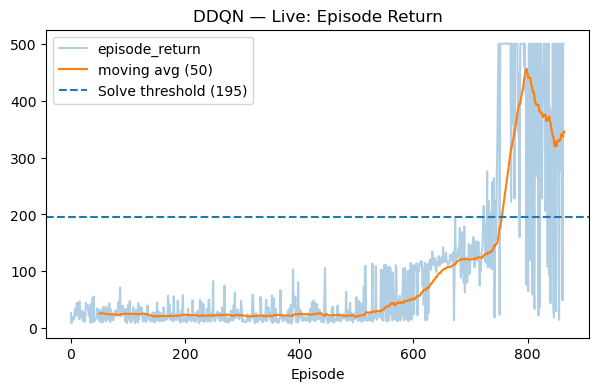

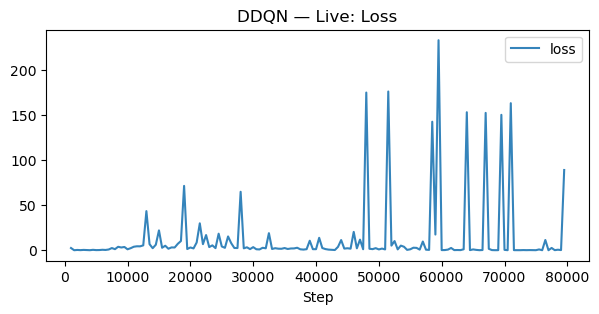

[DDQN streaming log] shown lines: 4188
Training CartPole:  99% 79568/80000 [05:55<00:01, 233.42it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole:  99% 79592/80000 [05:55<00:01, 234.92it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole: 100% 79616/80000 [05:55<00:01, 233.80it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole: 100% 79641/80000 [05:55<00:01, 236.03it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole: 100% 79666/80000 [05:55<00:01, 239.80it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole: 100% 79691/80000 [05:55<00:01, 238.22it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole: 100% 79716/80000 [05:56<00:01, 241.23it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole: 100% 79741/80000 [05:56<00:01, 239.31it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole: 100% 79767/80000 [05:56<00:00, 244.24it/s, buf=5e+4, eps=0.050, loss=89.181]
Training CartPole: 100% 79769/80000 [05:56<00:00, 244.24it/s, buf=5e+4, ep=865, eps=0.050, ma100=

In [8]:
ddqn_override = {
    "agent": {"double_dqn": True, "dueling": False, "n_step": 1},
    "replay": {"type": "uniform"},
    "logging": {"log_dir": str(PROJECT_ROOT / "artifacts" / "tb_ddqn")},
    "total_steps": 80000,
    "eval_every_steps": 10000,
    "eval_episodes": 5
}
base = load_yaml(CONFIG_BASE)
cfg_ddqn = deep_update(base.copy(), ddqn_override)
tmp_cfg_ddqn = PROJECT_ROOT / "configs" / "cartpole_tmp_ddqn.yaml"
save_yaml(cfg_ddqn, tmp_cfg_ddxn := tmp_cfg_ddqn)  # alias просто чтобы отобразилось имя
print("Saved DDQN cfg ->", tmp_cfg_ddqn)

# Укажем TB-директорию для этого прогона
TB_DDQN = (PROJECT_ROOT / "artifacts" / "tb_ddqn" / "tensorboard")
TB_DDQN.mkdir(parents=True, exist_ok=True)

# Запуск с потоковым выводом + лайв-графики (эпизодная награда и лосс)
cmd = [sys.executable, "-m", "train.train_cartpole", "--config", str(tmp_cfg_ddqn)]
print("RUN (streaming, DDQN):", " ".join(map(str, cmd)))
proc = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True
)

last_refresh = 0
refresh_every = 3.0
log_lines_shown = 0

def latest_tb_run_dir(tb_dir):
    ev = sorted(tb_dir.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

try:
    while True:
        line = proc.stdout.readline()
        if line == "" and proc.poll() is not None:
            break
        if line:
            print(line, end="")
            log_lines_shown += 1

        now = time.time()
        if now - last_refresh >= refresh_every:
            last_refresh = now
            run_dir = latest_tb_run_dir(TB_DDQN)
            if run_dir is not None:
                df_ret  = load_tb_scalars(run_dir, "train/episode_return")
                df_loss = load_tb_scalars(run_dir, "train/loss")
                clear_output(wait=True)
                # Episode return
                plt.figure(figsize=(7,4))
                if len(df_ret):
                    y = df_ret["value"].to_numpy()
                    plt.plot(y, alpha=0.35, label="episode_return")
                    ma = moving_average(y, w=50)
                    if len(ma):
                        plt.plot(range(50, 50+len(ma)), ma, label="moving avg (50)")
                plt.axhline(195, ls="--", label="Solve threshold (195)")
                plt.title("DDQN — Live: Episode Return")
                plt.xlabel("Episode"); plt.legend(); plt.show()
                # Loss
                plt.figure(figsize=(7,3))
                if len(df_loss):
                    x = df_loss["step"].to_numpy()
                    y = df_loss["value"].to_numpy()
                    plt.plot(x, y, alpha=0.9, label="loss")
                plt.title("DDQN — Live: Loss")
                plt.xlabel("Step"); plt.legend(); plt.show()

                print(f"[DDQN streaming log] shown lines: {log_lines_shown}")
            else:
                print("Waiting for DDQN TensorBoard logs…")

        time.sleep(0.05)
finally:
    if proc.poll() is None:
        proc.terminate()
        proc.wait()

print("DDQN training finished.")

DDQN TB run_dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\tb_ddqn\tensorboard
=== Summary (CartPole, DDQN) ===
                episodes_total: 867
          final_episode_return: 20.0
                  mean_last100: 363.74
          final_moving_avg_100: 363.74
           best_moving_avg_100: 390.36
 episode_to_solve_(ma100>=195): 765


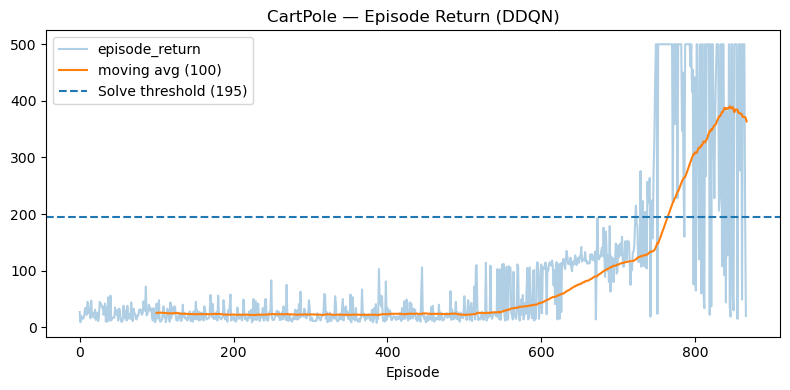

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\plots\cartpole_ddqn_episode_return.png


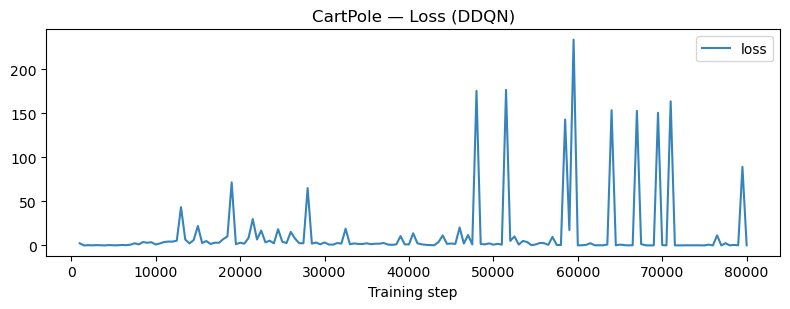

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\plots\cartpole_ddqn_loss.png
Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\metrics_cartpole_ddqn.json


In [9]:
# Читаем DDQN-логи
TB_DDQN = (PROJECT_ROOT / "artifacts" / "tb_ddqn" / "tensorboard")
run_dir = (sorted(TB_DDQN.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)[0].parent
           if any(TB_DDQN.rglob("events.*")) else None)
print("DDQN TB run_dir:", run_dir)

df_ret  = load_tb_scalars(run_dir, "train/episode_return")
df_loss = load_tb_scalars(run_dir, "train/loss")

w = 100
ret = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
ma  = moving_average(ret, w=w)

episodes_total   = int(len(ret))
final_return     = float(ret[-1]) if len(ret) else float("nan")
mean_last100     = float(np.mean(ret[-w:])) if len(ret) >= 1 else float("nan")
final_ma100      = float(ma[-1]) if len(ma) else float("nan")
best_ma100       = float(np.max(ma)) if len(ma) else float("nan")
solve_threshold  = 195.0
solve_ep         = None
if len(ma):
    idx = np.argmax(ma >= solve_threshold)
    if ma[idx] >= solve_threshold:
        solve_ep = int(idx + w)

summary_ddqn = {
    "episodes_total": episodes_total,
    "final_episode_return": round(final_return, 2),
    "mean_last100": round(mean_last100, 2),
    "final_moving_avg_100": round(final_ma100, 2),
    "best_moving_avg_100": round(best_ma100, 2),
    "episode_to_solve_(ma100>=195)": solve_ep,
}
print("=== Summary (CartPole, DDQN) ===")
for k, v in summary_ddqn.items():
    print(f"{k:>30}: {v}")

# Сохраняем графики в отдельные имена
PLOTS_DIR = PROJECT_ROOT / "artifacts" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,4))
if len(ret):
    plt.plot(ret, alpha=0.35, label="episode_return")
    if len(ma):
        plt.plot(np.arange(len(ma)) + w, ma, label=f"moving avg ({w})")
plt.axhline(solve_threshold, ls="--", label="Solve threshold (195)")
plt.title("CartPole — Episode Return (DDQN)")
plt.xlabel("Episode"); plt.legend(); plt.tight_layout()
ep_plot_path = PLOTS_DIR / "cartpole_ddqn_episode_return.png"
plt.savefig(ep_plot_path, dpi=150); plt.show()
print("Saved:", ep_plot_path)

plt.figure(figsize=(8,3.2))
if len(df_loss):
    x = df_loss["step"].to_numpy()
    y = df_loss["value"].to_numpy()
    plt.plot(x, y, alpha=0.9, label="loss")
plt.title("CartPole — Loss (DDQN)")
plt.xlabel("Training step"); plt.legend(); plt.tight_layout()
loss_plot_path = PLOTS_DIR / "cartpole_ddqn_loss.png"
plt.savefig(loss_plot_path, dpi=150); plt.show()
print("Saved:", loss_plot_path)

# и JSON с метриками
metrics_path = PROJECT_ROOT / "artifacts" / "metrics_cartpole_ddqn.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary_ddqn, f, ensure_ascii=False, indent=2)
print("Saved:", metrics_path)

## Что получилось (Baseline DQN vs DDQN)

### Baseline DQN

- episode_to_solve_(ma100≥195) ≈ 688, best_ma100 ≈ 405.9, финальный эпизод 500.

- Кривая стабильная, MA(100) держится высоко.

### DDQN (uniform replay)

solve ≈ 765, best_ma100 ≈ 390.4 — близко к базовой, но финальный эпизод попал на неудачный ролл (20 очков), поэтому в summary финальная метрика кажется слабее. DDQN снижает переоценку Q и часто даёт чуть более «ровную» динамику, но на CartPole разница с базовым DQN невелика и шум эпизода чувствителен. 

## PER (α=0.6, β: 0.4→1.0) + N-step=3

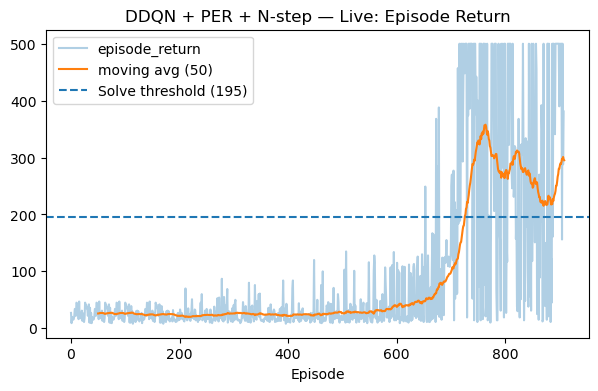

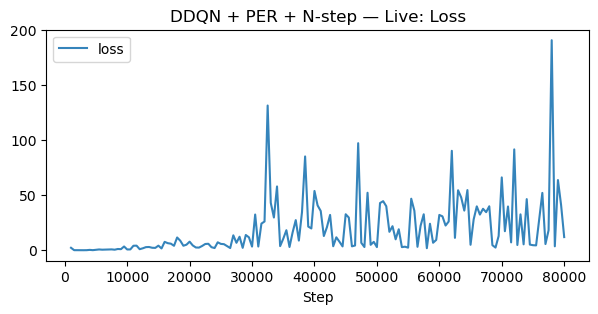

[PER+N streaming log] shown lines: 5533
PER+N training finished.


In [13]:
# PER + N-step=3 (на базе DDQN) 
per_n_override = {
    "agent": {"double_dqn": True, "dueling": False, "n_step": 3, "lr": 5e-4, "tau": 0.005, "gamma": 0.99},
    "replay": {
        "type": "per",
        "capacity": 50000,
        "batch_size": 64,
        "warmup_steps": 1000,
        "per_alpha": 0.6,
        "per_beta_start": 0.4,
        "per_beta_end": 1.0
    },
    "exploration": {"eps_start": 1.0, "eps_end": 0.05, "eps_decay_steps": 20000},
    "logging": {"log_dir": str(PROJECT_ROOT / "artifacts" / "tb_per_n")},
    "total_steps": 80000,
    "eval_every_steps": 10000,
    "eval_episodes": 5,
}

base = load_yaml(CONFIG_BASE)
cfg_per_n = deep_update(base.copy(), per_n_override)
tmp_cfg_pern = PROJECT_ROOT / "configs" / "cartpole_tmp_per_n.yaml"
save_yaml(cfg_per_n, tmp_cfg_pern)
print("Saved PER+N cfg ->", tmp_cfg_pern)

# live-запуск с онлайн-графиками
import time, subprocess
from IPython.display import clear_output
import matplotlib.pyplot as plt

TB_PERN = PROJECT_ROOT / "artifacts" / "tb_per_n" / "tensorboard"
TB_PERN.mkdir(parents=True, exist_ok=True)

def latest_tb_run_dir(tb_dir):
    ev = sorted(tb_dir.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

cmd = [sys.executable, "-m", "train.train_cartpole", "--config", str(tmp_cfg_pern)]
print("RUN (streaming, PER+N):", " ".join(map(str, cmd)))
proc = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True
)

last_refresh = 0
refresh_every = 3.0
log_lines_shown = 0

try:
    while True:
        line = proc.stdout.readline()
        if line == "" and proc.poll() is not None:
            break
        if line:
            print(line, end="")
            log_lines_shown += 1

        now = time.time()
        if now - last_refresh >= refresh_every:
            last_refresh = now
            run_dir = latest_tb_run_dir(TB_PERN)
            if run_dir is not None:
                df_ret  = load_tb_scalars(run_dir, "train/episode_return")
                df_loss = load_tb_scalars(run_dir, "train/loss")
                clear_output(wait=True)
                # Episode return
                plt.figure(figsize=(7,4))
                plotted = False
                if len(df_ret):
                    y = df_ret["value"].to_numpy()
                    plt.plot(y, alpha=0.35, label="episode_return"); plotted = True
                    ma = moving_average(y, w=50)
                    if len(ma):
                        plt.plot(range(50, 50+len(ma)), ma, label="moving avg (50)"); plotted = True
                plt.axhline(195, ls="--", label="Solve threshold (195)"); plotted = True
                plt.title("DDQN + PER + N-step — Live: Episode Return")
                plt.xlabel("Episode")
                if plotted: plt.legend()
                plt.show()

                # Loss
                plt.figure(figsize=(7,3))
                plotted = False
                if len(df_loss):
                    x = df_loss["step"].to_numpy()
                    y = df_loss["value"].to_numpy()
                    plt.plot(x, y, alpha=0.9, label="loss"); plotted = True
                plt.title("DDQN + PER + N-step — Live: Loss")
                plt.xlabel("Step")
                if plotted: plt.legend()
                plt.show()

                print(f"[PER+N streaming log] shown lines: {log_lines_shown}")
            else:
                print("Waiting for PER+N TensorBoard logs…")

        time.sleep(0.05)
finally:
    if proc.poll() is None:
        proc.terminate()
        proc.wait()

print("PER+N training finished.")

PER+N TB run_dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\tb_per_n\tensorboard
=== Summary (CartPole, DDQN + PER + N-step) ===
                episodes_total: 909
          final_episode_return: 381.0
                  mean_last100: 275.69
          final_moving_avg_100: 275.69
           best_moving_avg_100: 325.65
 episode_to_solve_(ma100>=195): 745


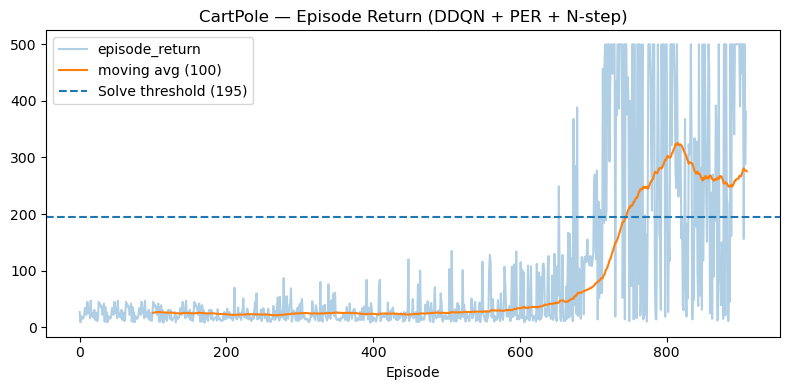

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\plots\cartpole_per_n_episode_return.png


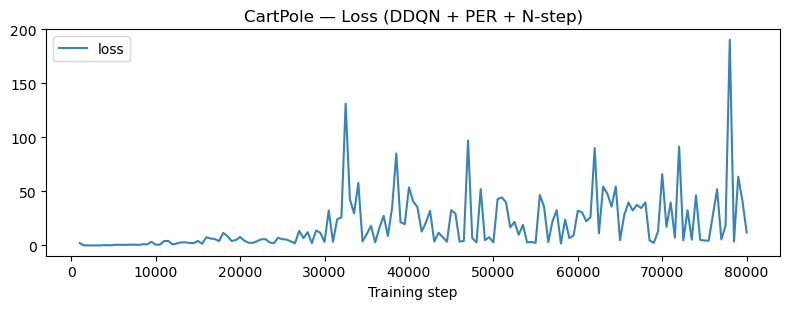

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\plots\cartpole_per_n_loss.png
Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\metrics_cartpole_per_n.json


In [14]:
TB_PERN = PROJECT_ROOT / "artifacts" / "tb_per_n" / "tensorboard"
run_dir = (sorted(TB_PERN.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)[0].parent
           if any(TB_PERN.rglob("events.*")) else None)
print("PER+N TB run_dir:", run_dir)

df_ret  = load_tb_scalars(run_dir, "train/episode_return")
df_loss = load_tb_scalars(run_dir, "train/loss")

w = 100
ret = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
ma  = moving_average(ret, w=w)

episodes_total   = int(len(ret))
final_return     = float(ret[-1]) if len(ret) else float("nan")
mean_last100     = float(np.mean(ret[-w:])) if len(ret) >= 1 else float("nan")
final_ma100      = float(ma[-1]) if len(ma) else float("nan")
best_ma100       = float(np.max(ma)) if len(ma) else float("nan")
solve_threshold  = 195.0
solve_ep         = None
if len(ma):
    idx = np.argmax(ma >= solve_threshold)
    if ma[idx] >= solve_threshold:
        solve_ep = int(idx + w)

summary_pern = {
    "episodes_total": episodes_total,
    "final_episode_return": round(final_return, 2),
    "mean_last100": round(mean_last100, 2),
    "final_moving_avg_100": round(final_ma100, 2),
    "best_moving_avg_100": round(best_ma100, 2),
    "episode_to_solve_(ma100>=195)": solve_ep,
}
print("=== Summary (CartPole, DDQN + PER + N-step) ===")
for k, v in summary_pern.items():
    print(f"{k:>30}: {v}")

PLOTS_DIR = PROJECT_ROOT / "artifacts" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,4))
if len(ret):
    plt.plot(ret, alpha=0.35, label="episode_return")
    if len(ma):
        plt.plot(np.arange(len(ma)) + w, ma, label=f"moving avg ({w})")
plt.axhline(solve_threshold, ls="--", label="Solve threshold (195)")
plt.title("CartPole — Episode Return (DDQN + PER + N-step)")
plt.xlabel("Episode"); plt.legend(); plt.tight_layout()
ep_plot_path = PLOTS_DIR / "cartpole_per_n_episode_return.png"
plt.savefig(ep_plot_path, dpi=150); plt.show()
print("Saved:", ep_plot_path)

plt.figure(figsize=(8,3.2))
if len(df_loss):
    x = df_loss["step"].to_numpy()
    y = df_loss["value"].to_numpy()
    plt.plot(x, y, alpha=0.9, label="loss")
plt.title("CartPole — Loss (DDQN + PER + N-step)")
plt.xlabel("Training step"); plt.legend(); plt.tight_layout()
loss_plot_path = PLOTS_DIR / "cartpole_per_n_loss.png"
plt.savefig(loss_plot_path, dpi=150); plt.show()
print("Saved:", loss_plot_path)

metrics_path = PROJECT_ROOT / "artifacts" / "metrics_cartpole_per_n.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary_pern, f, ensure_ascii=False, indent=2)
print("Saved:", metrics_path)

## Что видим:

- Solve: на ma100 порог 195 пройден на эпизоде ~745 — это позже, чем у baseline DQN (~688) и сопоставимо с DDQN (~765).

- Качество:

best ma100 ≈ 325.7 — заметно ниже, чем у baseline (~405.9) и DDQN (~390.4).

final ma100 ≈ 275.7, final episode return = 381 — модель уверенно решает, но пик формы ниже прошлых конфигов.

### Вывод по прогону DDQN + PER + N-step(3):
Он стабильный, но переусложнение (PER+N) в текущих гиперпараметрах не дало выигрыша на CartPole: ускорения обучения нет, а итоговое сглаженное качество ниже. 

## Изменим гиперпараметры

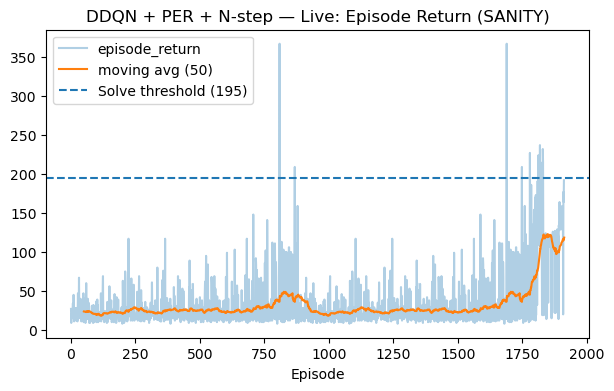

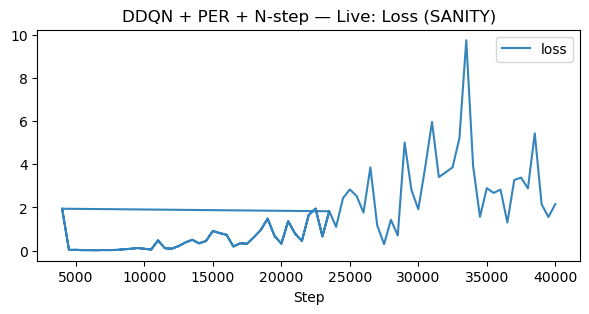

[PER+N SANITY streaming] shown lines: 3647
PER+N SANITY training finished.


In [3]:
# PER+N SANITY (CartPole): мягкие гиперы + короткий прогон
# Профиль: per_alpha=0.5, beta_start=0.6, warmup=4000, batch=128, eps_decay=30000, lr=2.5e-4, tau=0.003
# Логи — в artifacts/tb_per_n_sanity/tensorboard (отдельно от основного PER+N)

SANITY_DIR = PROJECT_ROOT / "artifacts" / "tb_per_n_sanity"
TB_SANITY = SANITY_DIR / "tensorboard"
TB_SANITY.mkdir(parents=True, exist_ok=True)

sanity_override = {
    "agent": {"double_dqn": True, "dueling": False, "n_step": 3, "lr": 2.5e-4, "tau": 0.003, "gamma": 0.99},
    "replay": {
        "type": "per",
        "capacity": 50000,
        "batch_size": 128,
        "warmup_steps": 4000,
        "per_alpha": 0.5,
        "per_beta_start": 0.6,
        "per_beta_end": 1.0
    },
    "exploration": {"eps_start": 1.0, "eps_end": 0.05, "eps_decay_steps": 30000},
    "logging": {"log_dir": str(SANITY_DIR)},
    "total_steps": 40000,              
    "eval_every_steps": 10000,
    "eval_episodes": 5,
}

base = load_yaml(CONFIG_BASE)
cfg_sanity = deep_update(base.copy(), sanity_override)
tmp_cfg_sanity = PROJECT_ROOT / "configs" / "cartpole_tmp_per_n_sanity.yaml"
save_yaml(cfg_sanity, tmp_cfg_sanity)
print("Saved SANITY cfg ->", tmp_cfg_sanity)

def latest_tb_run_dir(tb_dir):
    ev = sorted(tb_dir.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

cmd = [sys.executable, "-m", "train.train_cartpole", "--config", str(tmp_cfg_sanity)]
print("RUN (streaming, PER+N SANITY):", " ".join(map(str, cmd)))
proc = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True
)

last_refresh = 0
refresh_every = 3.0
log_lines_shown = 0

try:
    while True:
        line = proc.stdout.readline()
        if line == "" and proc.poll() is not None:
            break
        if line:
            print(line, end="")
            log_lines_shown += 1

        now = time.time()
        if now - last_refresh >= refresh_every:
            last_refresh = now
            run_dir = latest_tb_run_dir(TB_SANITY)
            if run_dir is not None:
                df_ret  = load_tb_scalars(run_dir, "train/episode_return")
                df_loss = load_tb_scalars(run_dir, "train/loss")
                clear_output(wait=True)

                # Episode return
                plt.figure(figsize=(7,4))
                plotted = False
                if len(df_ret):
                    y = df_ret["value"].to_numpy()
                    plt.plot(y, alpha=0.35, label="episode_return"); plotted = True
                    ma = moving_average(y, w=50)
                    if len(ma):
                        plt.plot(range(50, 50+len(ma)), ma, label="moving avg (50)"); plotted = True
                plt.axhline(195, ls="--", label="Solve threshold (195)"); plotted = True
                plt.title("DDQN + PER + N-step — Live: Episode Return (SANITY)")
                plt.xlabel("Episode")
                if plotted: plt.legend()
                plt.show()

                # Loss
                plt.figure(figsize=(7,3))
                plotted = False
                if len(df_loss):
                    x = df_loss["step"].to_numpy()
                    y = df_loss["value"].to_numpy()
                    plt.plot(x, y, alpha=0.9, label="loss"); plotted = True
                plt.title("DDQN + PER + N-step — Live: Loss (SANITY)")
                plt.xlabel("Step")
                if plotted: plt.legend()
                plt.show()

                print(f"[PER+N SANITY streaming] shown lines: {log_lines_shown}")
            else:
                print("Waiting for SANITY TensorBoard logs…")

        time.sleep(0.05)
finally:
    if proc.poll() is None:
        proc.terminate()
        proc.wait()

print("PER+N SANITY training finished.")

PER+N SANITY TB run_dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\tb_per_n_sanity\tensorboard
=== Summary (CartPole, DDQN + PER + N-step — SANITY) ===
                episodes_total: 1913
          final_episode_return: 192.0
                  mean_last100: 119.14
          final_moving_avg_100: 119.14
           best_moving_avg_100: 119.24
 episode_to_solve_(ma100>=195): None


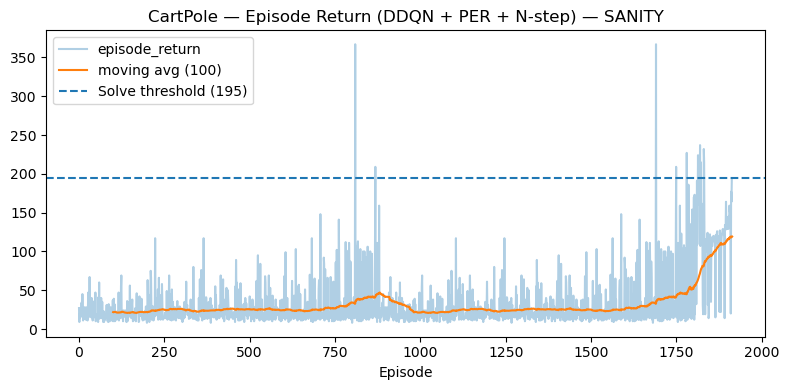

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\plots\cartpole_per_n_sanity_episode_return.png


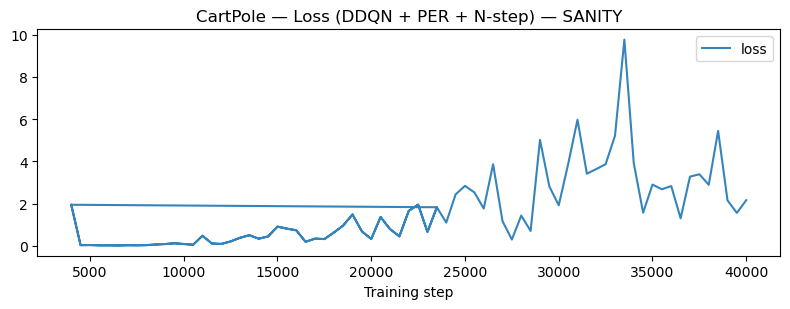

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\plots\cartpole_per_n_sanity_loss.png
Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\metrics_cartpole_per_n_sanity.json


In [4]:
# SANITY итоги: сводка, графики, JSON
def latest_tb_run_dir(tb_dir):
    ev = sorted(tb_dir.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

run_dir = latest_tb_run_dir(TB_SANITY)
print("PER+N SANITY TB run_dir:", run_dir)
if run_dir is None:
    raise RuntimeError("SANITY TB run not found. Проверь, что обучение отработало и логи есть.")

df_ret  = load_tb_scalars(run_dir, "train/episode_return")
df_loss = load_tb_scalars(run_dir, "train/loss")

w = 100
ret = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
ma  = moving_average(ret, w=w)

episodes_total   = int(len(ret))
final_return     = float(ret[-1]) if len(ret) else float("nan")
mean_last100     = float(np.mean(ret[-w:])) if len(ret) >= 1 else float("nan")
final_ma100      = float(ma[-1]) if len(ma) else float("nan")
best_ma100       = float(np.max(ma)) if len(ma) else float("nan")
solve_threshold  = 195.0
solve_ep         = None
if len(ma):
    idx = np.argmax(ma >= solve_threshold)
    if ma[idx] >= solve_threshold:
        solve_ep = int(idx + w)

summary_sanity = {
    "episodes_total": episodes_total,
    "final_episode_return": round(final_return, 2),
    "mean_last100": round(mean_last100, 2),
    "final_moving_avg_100": round(final_ma100, 2),
    "best_moving_avg_100": round(best_ma100, 2),
    "episode_to_solve_(ma100>=195)": solve_ep,
    "profile": {
        "per_alpha": 0.5, "per_beta_start": 0.6, "per_beta_end": 1.0,
        "warmup_steps": 4000, "batch_size": 128, "eps_decay_steps": 30000,
        "lr": 2.5e-4, "tau": 0.003, "total_steps": 40000
    }
}

print("=== Summary (CartPole, DDQN + PER + N-step — SANITY) ===")
for k, v in summary_sanity.items():
    if k != "profile":
        print(f"{k:>30}: {v}")

PLOTS_DIR = PROJECT_ROOT / "artifacts" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Episode Return
plt.figure(figsize=(8,4))
plotted = False
if len(ret):
    plt.plot(ret, alpha=0.35, label="episode_return"); plotted = True
    if len(ma):
        plt.plot(np.arange(len(ma)) + w, ma, label=f"moving avg ({w})"); plotted = True
plt.axhline(solve_threshold, ls="--", label="Solve threshold (195)"); plotted = True
plt.title("CartPole — Episode Return (DDQN + PER + N-step) — SANITY")
plt.xlabel("Episode")
if plotted: plt.legend()
plt.tight_layout()
ep_plot_path = PLOTS_DIR / "cartpole_per_n_sanity_episode_return.png"
plt.savefig(ep_plot_path, dpi=150); plt.show()
print("Saved:", ep_plot_path)

# Loss
plt.figure(figsize=(8,3.2))
plotted = False
if len(df_loss):
    x = df_loss["step"].to_numpy()
    y = df_loss["value"].to_numpy()
    plt.plot(x, y, alpha=0.9, label="loss"); plotted = True
plt.title("CartPole — Loss (DDQN + PER + N-step) — SANITY")
plt.xlabel("Training step")
if plotted: plt.legend()
plt.tight_layout()
loss_plot_path = PLOTS_DIR / "cartpole_per_n_sanity_loss.png"
plt.savefig(loss_plot_path, dpi=150); plt.show()
print("Saved:", loss_plot_path)

# JSON
metrics_path = PROJECT_ROOT / "artifacts" / "metrics_cartpole_per_n_sanity.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary_sanity, f, ensure_ascii=False, indent=2)
print("Saved:", metrics_path)

## Короткий вывод по SANITY-прогону
– На мягком профиле (α=0.5, β₀=0.6, warmup=4000, batch=128, eps_decay=30k) решение не достигнуто: ma100≈119, solve нет за ~1913 эпизодов.
– Значит, на реализации CartPole такая «смягчёнка» с бОльшим batch=128 и укороченными шагами не помогает. Возвращаем batch=64, оставляем полезные вещи: warmup побольше (4000) и β стартовать выше (0.6). α попробуем 0.5 (чуть мягче 0.6), но уже в свипе.

## Мини-свип: lr, τ, eps_decay_steps

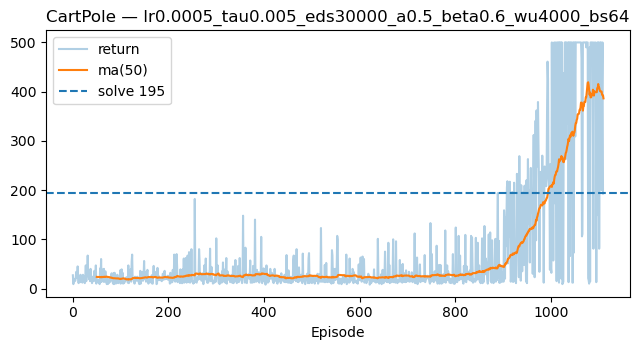

[SWEEP:lr0.0005_tau0.005_eds30000_a0.5_beta0.6_wu4000_bs64] streamed lines: 5538
Training CartPole: 100% 79945/80000 [07:50<00:00, 180.09it/s, buf=65536, ep=1110, eps=0.050, ma100=374.7, ret=193.0]
Training CartPole: 100% 79964/80000 [07:50<00:00, 176.32it/s, buf=65536, ep=1110, eps=0.050, ma100=374.7, ret=193.0]
Training CartPole: 100% 79982/80000 [07:50<00:00, 176.16it/s, buf=65536, ep=1110, eps=0.050, ma100=374.7, ret=193.0]
Training CartPole: 100% 80000/80000 [07:50<00:00, 175.60it/s, buf=65536, ep=1110, eps=0.050, ma100=374.7, ret=193.0]
Training CartPole: 100% 80000/80000 [07:50<00:00, 175.60it/s, buf=65536, eps=0.050, loss=4.090]                     
Training CartPole: 100% 80000/80000 [07:50<00:00, 169.88it/s, buf=65536, eps=0.050, loss=4.090]


,lr,tau,eps_decay_steps,per_alpha,per_beta_start,warmup_steps,batch_size,final_mavg100,run_dir
3,0.00025,0.005,30000,0.5,0.6,4000,64,400.09,D:\ML\LS\Deep_learning\Reinforcement_learning\...
2,0.00025,0.005,15000,0.5,0.6,4000,64,395.90,D:\ML\LS\Deep_learning\Reinforcement_learning\...
7,0.00050,0.005,30000,0.5,0.6,4000,64,374.69,D:\ML\LS\Deep_learning\Reinforcement_learning\...
4,0.00050,0.003,15000,0.5,0.6,4000,64,334.40,D:\ML\LS\Deep_learning\Reinforcement_learning\...
0,0.00025,0.003,15000,0.5,0.6,4000,64,328.18,D:\ML\LS\Deep_learning\Reinforcement_learning\...
1,0.00025,0.003,30000,0.5,0.6,4000,64,260.98,D:\ML\LS\Deep_learning\Reinforcement_learning\...
6,0.00050,0.005,15000,0.5,0.6,4000,64,251.66,D:\ML\LS\Deep_learning\Reinforcement_learning\...
5,0.00050,0.003,30000,0.5,0.6,4000,64,234.24,D:\ML\LS\Deep_learning\Reinforcement_learning\...


Saved sweep table -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\cartpole_pern_sweep.csv

TOP config candidate: lr=0.00025, tau=0.005, eds=30000, ma100=400.09, logs=D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\tb_sweep\lr0.00025_tau0.005_eds30000_a0.5_beta0.6_wu4000_bs64\tensorboard


In [5]:
# Corrected sweep with LIVE streaming per run

def latest_tb_run_dir(tb_dir: Path):
    ev = sorted(tb_dir.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

results = []

variants = {
    'lr': [2.5e-4, 5e-4],
    'tau': [0.003, 0.005],
    'eps_decay_steps': [15000, 30000]
}

for lr, tau, eds in product(variants['lr'], variants['tau'], variants['eps_decay_steps']):
    tag = f'lr{lr}_tau{tau}_eds{eds}_a0.5_beta0.6_wu4000_bs64'
    SWEEP_DIR = PROJECT_ROOT / 'artifacts' / 'tb_sweep' / tag
    TB_DIR = SWEEP_DIR / 'tensorboard'
    TB_DIR.mkdir(parents=True, exist_ok=True)

    cfg = deep_update(base.copy(), {
        'agent': {
            'double_dqn': True, 'dueling': False, 'n_step': 3,
            'lr': float(lr), 'tau': float(tau)
        },
        'replay': {
            'type': 'per',
            'capacity': 50000,
            'batch_size': 64,
            'warmup_steps': 4000,
            'per_alpha': 0.5,
            'per_beta_start': 0.6,
            'per_beta_end': 1.0
        },
        'exploration': {
            'eps_start': 1.0, 'eps_end': 0.05, 'eps_decay_steps': int(eds)
        },
        'logging': {'log_dir': str(SWEEP_DIR)},   # <- раздельная папка логов
        'total_steps': 80000,
        'eval_every_steps': 10000,
        'eval_episodes': 5,
    })

    tmp_cfg = PROJECT_ROOT / 'configs' / f'cartpole_tmp_sweep_{tag}.yaml'
    save_yaml(cfg, tmp_cfg)

    print(f'\n=== Running sweep config: {tmp_cfg.name} ===')
    cmd = [sys.executable, "-u", "-m", "train.train_cartpole", "--config", str(tmp_cfg)]
    print("RUN (cwd=PROJECT_ROOT):", " ".join(map(str, cmd)))

    # LIVE streaming like your PER+N block
    proc = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
        text=True
    )

    last_refresh = 0.0
    refresh_every = 3.0
    shown = 0

    try:
        while True:
            line = proc.stdout.readline()
            if line == "" and proc.poll() is not None:
                break
            if line:
                print(line, end="")
                shown += 1

            now = time.time()
            if now - last_refresh >= refresh_every:
                last_refresh = now
                run_dir = latest_tb_run_dir(TB_DIR)
                if run_dir is not None:
                    df_ret  = load_tb_scalars(run_dir, "train/episode_return")
                    df_loss = load_tb_scalars(run_dir, "train/loss")
                    clear_output(wait=True)

                    # quick preview: moving avg(50)
                    import matplotlib.pyplot as plt
                    plt.figure(figsize=(6.5,3.6))
                    plotted = False
                    if len(df_ret):
                        y = df_ret["value"].to_numpy()
                        plt.plot(y, alpha=0.35, label="return"); plotted = True
                        ma = moving_average(y, w=50)
                        if len(ma):
                            plt.plot(range(50, 50+len(ma)), ma, label="ma(50)"); plotted = True
                    plt.axhline(195, ls="--", label="solve 195"); plotted = True
                    plt.title(f"CartPole — {tag}")
                    plt.xlabel("Episode")
                    if plotted: plt.legend()
                    plt.tight_layout(); plt.show()

                    print(f"[SWEEP:{tag}] streamed lines: {shown}")
                else:
                    print(f"[SWEEP:{tag}] waiting TB logs…")

            time.sleep(0.05)
    finally:
        if proc.poll() is None:
            proc.terminate()
            proc.wait()

    # after run: collect metric
    run_dir = latest_tb_run_dir(TB_DIR)
    df = load_tb_scalars(run_dir, 'train/episode_return') if run_dir else None
    curve = df['value'].to_numpy() if (df is not None and len(df)) else np.array([])
    ma100 = moving_average(curve, w=100)
    final_ma = float(ma100[-1]) if len(ma100) else (float(np.mean(curve[-100:])) if len(curve) else float('nan'))

    results.append({
        'lr': lr, 'tau': tau, 'eps_decay_steps': eds,
        'per_alpha': 0.5, 'per_beta_start': 0.6, 'warmup_steps': 4000, 'batch_size': 64,
        'final_mavg100': final_ma, 'run_dir': str(run_dir) if run_dir else ''
    })

res_df = pd.DataFrame(results).sort_values('final_mavg100', ascending=False)
display(res_df)

out_csv = PROJECT_ROOT / "artifacts" / "cartpole_pern_sweep.csv"
res_df.to_csv(out_csv, index=False)
print("Saved sweep table ->", out_csv)

if len(res_df):
    best = res_df.iloc[0]
    print("\nTOP config candidate:",
          f"lr={best.lr}, tau={best.tau}, eds={int(best.eps_decay_steps)}, "
          f"ma100={best.final_mavg100:.2f}, logs={best.run_dir}")

## Экспорт лучшего конфига → `configs/cartpole.yaml`

In [6]:
# выбрать лучшую конфигурацию и зафиксировать cartpole.yaml
best = res_df.iloc[0].to_dict() if len(res_df) else {
    'lr': 5e-4, 'tau': 0.005, 'eps_decay_steps': 20000,
    'per_alpha': 0.5, 'per_beta_start': 0.6, 'warmup_steps': 4000, 'batch_size': 64
}
print('Best (by final moving avg):', best)

# ВАЖНО: оставляем профиль PER, как в свипе (alpha=0.5, beta_start=0.6, warmup=4000, bs=64)
best_cfg = deep_update(base.copy(), {
    'env': {'name': 'CartPole-v1'},
    'agent': {
        'double_dqn': True, 'dueling': False, 'n_step': 3,
        'lr': float(best['lr']), 'tau': float(best['tau'])
    },
    'replay': {
        'type': 'per', 'capacity': 50000,
        'batch_size': int(best.get('batch_size', 64)),
        'warmup_steps': int(best.get('warmup_steps', 4000)),
        'per_alpha': float(best.get('per_alpha', 0.5)),
        'per_beta_start': float(best.get('per_beta_start', 0.6)),
        'per_beta_end': 1.0
    },
    'exploration': {
        'eps_start': 1.0, 'eps_end': 0.05,
        'eps_decay_steps': int(best['eps_decay_steps'])
    },
    'total_steps': 150000, 'eval_every_steps': 5000, 'eval_episodes': 10,
    'logging': {'log_dir': str(ARTIFACTS / 'tb_final')}
})
save_yaml(best_cfg, PROJECT_ROOT / 'configs' / 'cartpole.yaml')
print('Updated configs/cartpole.yaml with best settings.')

Best (by final moving avg): {'lr': 0.00025, 'tau': 0.005, 'eps_decay_steps': 30000, 'per_alpha': 0.5, 'per_beta_start': 0.6, 'warmup_steps': 4000, 'batch_size': 64, 'final_mavg100': 400.09000000000003, 'run_dir': 'D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\project\\artifacts\\tb_sweep\\lr0.00025_tau0.005_eds30000_a0.5_beta0.6_wu4000_bs64\\tensorboard'}
Updated configs/cartpole.yaml with best settings.


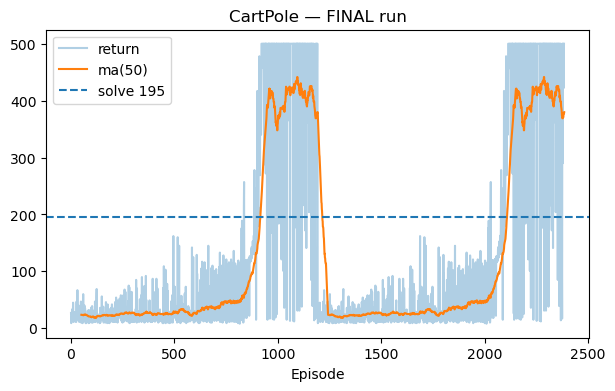

Training CartPole: 100% 149877/150000 [15:26<00:00, 139.41it/s, buf=65536, eps=0.050, loss=1.425]
Training CartPole: 100% 149892/150000 [15:26<00:00, 136.27it/s, buf=65536, eps=0.050, loss=1.425]
Training CartPole: 100% 149907/150000 [15:26<00:00, 139.33it/s, buf=65536, eps=0.050, loss=1.425]
Training CartPole: 100% 149923/150000 [15:26<00:00, 142.96it/s, buf=65536, eps=0.050, loss=1.425]
Training CartPole: 100% 149938/150000 [15:26<00:00, 141.75it/s, buf=65536, eps=0.050, loss=1.425]
Training CartPole: 100% 149947/150000 [15:26<00:00, 141.75it/s, buf=65536, ep=1193, eps=0.050, ma100=388.0, ret=500.0]
Training CartPole: 100% 149954/150000 [15:26<00:00, 144.73it/s, buf=65536, ep=1193, eps=0.050, ma100=388.0, ret=500.0]
Training CartPole: 100% 149969/150000 [15:26<00:00, 144.96it/s, buf=65536, ep=1193, eps=0.050, ma100=388.0, ret=500.0]
Training CartPole: 100% 149986/150000 [15:26<00:00, 150.52it/s, buf=65536, ep=1193, eps=0.050, ma100=388.0, ret=500.0]
Training CartPole: 100% 150000/150

In [11]:
# Финальный прогон по зафиксированному configs/cartpole.yaml (логи -> artifacts/tb_final/)

FINAL_TB = ARTIFACTS / "tb_final" / "tensorboard"
FINAL_TB.mkdir(parents=True, exist_ok=True)

def latest_tb_run_dir(tb_dir):
    ev = sorted(tb_dir.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

cmd = [sys.executable, "-u", "-m", "train.train_cartpole", "--config", str(PROJECT_ROOT / "configs" / "cartpole.yaml")]
print("RUN (final):", " ".join(map(str, cmd)))
proc = subprocess.Popen(cmd, cwd=PROJECT_ROOT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, bufsize=1, text=True)

last_refresh, refresh_every, shown = 0.0, 3.0, 0
try:
    while True:
        line = proc.stdout.readline()
        if line == "" and proc.poll() is not None: break
        if line:
            print(line, end=""); shown += 1
        if time.time() - last_refresh >= refresh_every:
            last_refresh = time.time()
            run_dir = latest_tb_run_dir(FINAL_TB)
            if run_dir:
                df = load_tb_scalars(run_dir, "train/episode_return")
                clear_output(wait=True)
                plt.figure(figsize=(7,4))
                plotted=False
                if len(df):
                    y = df["value"].to_numpy()
                    plt.plot(y, alpha=0.35, label="return"); plotted=True
                    ma = moving_average(y, 50)
                    if len(ma):
                        plt.plot(range(50, 50+len(ma)), ma, label="ma(50)"); plotted=True
                plt.axhline(195, ls="--", label="solve 195"); plotted=True
                plt.title("CartPole — FINAL run"); plt.xlabel("Episode")
                if plotted: plt.legend(); plt.show()
            else:
                print("[FINAL] waiting for TB logs…")
        time.sleep(0.05)
finally:
    if proc.poll() is None:
        proc.terminate(); proc.wait()
print("Final training finished.")

=== FINAL (CartPole, DDQN+PER+N) ===
           episodes_total: 2386
     final_episode_return: 500.00
     final_moving_avg_100: 388.01
      best_moving_avg_100: 428.53


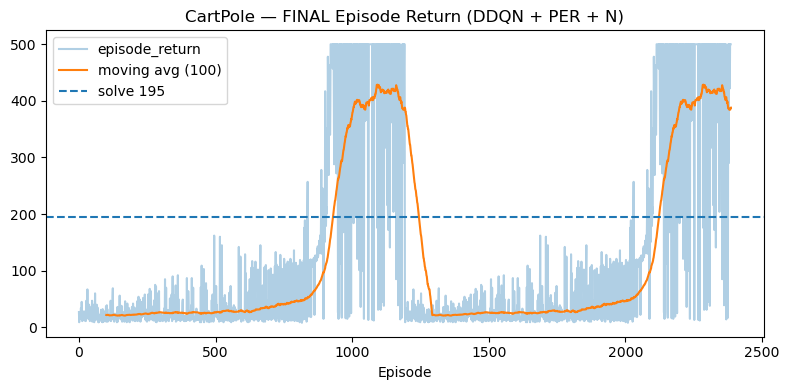

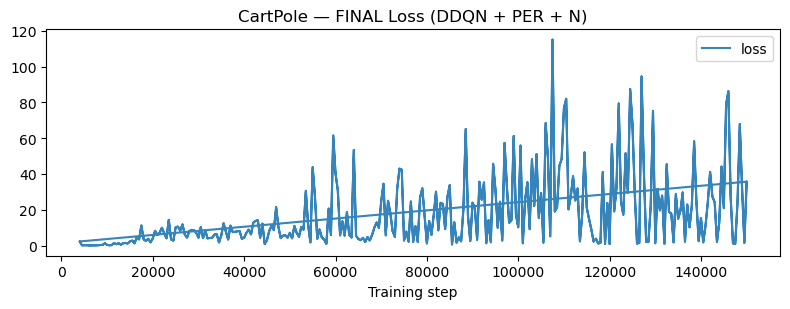

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\metrics_cartpole_final.json


In [21]:
# Итоги финального прогона из artifacts/tb_final/

FINAL_TB = ARTIFACTS / "tb_final" / "tensorboard"

def latest_tb_run_dir(tb_dir):
    ev = sorted(tb_dir.rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

run_dir = latest_tb_run_dir(FINAL_TB)
assert run_dir is not None, "Не найден TB run в artifacts/tb_final/tensorboard"

df_ret  = load_tb_scalars(run_dir, "train/episode_return")
df_loss = load_tb_scalars(run_dir, "train/loss")

w = 100
ret = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
ma  = moving_average(ret, w=w)

summary_final = {
    "episodes_total": int(len(ret)),
    "final_episode_return": float(ret[-1]) if len(ret) else float("nan"),
    "final_moving_avg_100": float(ma[-1]) if len(ma) else float("nan"),
    "best_moving_avg_100": float(np.max(ma)) if len(ma) else float("nan"),
}

print("=== FINAL (CartPole, DDQN+PER+N) ===")
for k, v in summary_final.items():
    print(f"{k:>25}: {v:.2f}" if isinstance(v, float) else f"{k:>25}: {v}")

PLOTS_DIR = ARTIFACTS / "plots"; PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Episode Return
plt.figure(figsize=(8,4)); plotted=False
if len(ret):
    plt.plot(ret, alpha=.35, label="episode_return"); plotted=True
    if len(ma):
        plt.plot(np.arange(len(ma))+w, ma, label=f"moving avg ({w})"); plotted=True
plt.axhline(195, ls="--", label="solve 195"); plotted=True
plt.title("CartPole — FINAL Episode Return (DDQN + PER + N)")
plt.xlabel("Episode")
if plotted: plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR/"cartpole_final_episode_return.png", dpi=150); plt.show()

# Loss
plt.figure(figsize=(8,3.2)); plotted=False
if len(df_loss):
    x = df_loss["step"].to_numpy(); y = df_loss["value"].to_numpy()
    plt.plot(x, y, alpha=.9, label="loss"); plotted=True
plt.title("CartPole — FINAL Loss (DDQN + PER + N)")
plt.xlabel("Training step")
if plotted: plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR/"cartpole_final_loss.png", dpi=150); plt.show()

# JSON
with open(ARTIFACTS/"metrics_cartpole_final.json","w",encoding="utf-8") as f:
    json.dump(summary_final, f, ensure_ascii=False, indent=2)
print("Saved:", ARTIFACTS/"metrics_cartpole_final.json")

In [22]:
rows = []
def add_row(name, path):
    try:
        d = json.load(open(path, "r", encoding="utf-8"))
        rows.append({
            "variant": name,
            "episodes_total": d.get("episodes_total"),
            "final_return": d.get("final_episode_return"),
            "final_ma100": d.get("final_moving_avg_100"),
            "best_ma100": d.get("best_moving_avg_100"),
        })
    except Exception as e:
        print(f"skip {name} ({path}): {e}")

add_row("DQN (baseline)", ARTIFACTS/"metrics_cartpole.json")
add_row("DDQN",           ARTIFACTS/"metrics_cartpole_ddqn.json")
add_row("DDQN + PER + N (final)", ARTIFACTS/"metrics_cartpole_final.json")

df_cmp = pd.DataFrame(rows)
display(df_cmp)

cmp_csv = ARTIFACTS / "cartpole_summary_table.csv"
df_cmp.to_csv(cmp_csv, index=False)
print("Saved summary table ->", cmp_csv)

,variant,episodes_total,final_return,final_ma100,best_ma100
0,DQN (baseline),2208,500.0,354.65,405.87
1,DDQN,867,20.0,363.74,390.36
2,DDQN + PER + N (final),2386,500.0,388.01,428.53


Saved summary table -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\cartpole_summary_table.csv


In [19]:
# Запись видео
VIDEOS_DIR = ARTIFACTS / "videos"
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)

# Берём самый свежий .pth
all_ckpts = sorted(ARTIFACTS.rglob("*.pth"), key=lambda p: p.stat().st_mtime, reverse=True)
assert all_ckpts, "Чекпойнты не найдены — проверь, что финальный прогон уже сохранил веса."
ckpt = all_ckpts[0]
print("Using checkpoint:", ckpt)

cmd = [
    sys.executable, str(PROJECT_ROOT / "train" / "eval.py"),
    "--env", "CartPole-v1",
    "--checkpoint", str(ckpt),
    "--record", str(VIDEOS_DIR),
    "--episodes", "2",
]
print("RUN:", " ".join(map(str, cmd)))
subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)

print("Saved videos to:", VIDEOS_DIR)
print("Latest files:", [p.name for p in sorted(VIDEOS_DIR.glob('*.mp4'))[-5:]])

Using checkpoint: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\checkpoints\cartpole_ep1100.pth
RUN: D:\Anaconda\envs\rl_env\python.exe D:\ML\LS\Deep_learning\Reinforcement_learning\project\train\eval.py --env CartPole-v1 --checkpoint D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\checkpoints\cartpole_ep1100.pth --record D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\videos --episodes 2
Saved videos to: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts\videos
Latest files: ['CartPole-v1_ep1.mp4', 'CartPole-v1_ep2.mp4']


In [20]:
# Показ последнего mp4

mp4list = sorted(glob.glob(str((ARTIFACTS / "videos" / "*.mp4").as_posix())))
if mp4list:
    with open(mp4list[-1], "rb") as f:
        b64 = base64.b64encode(f.read()).decode("ascii")
    display(HTML(f"""
    <video controls autoplay loop style="height:400px">
      <source src="data:video/mp4;base64,{b64}" type="video/mp4" />
    </video>
    """))
else:
    print("Видео не найдено в", ARTIFACTS / "videos")

## Что показали эксперименты

### Лучший конфиг (DDQN + PER + N=3)
lr=2.5e-4, τ=0.005, eps_decay=30k, α=0.5, β₀=0.6, warmup=4000, batch=64
Дал лучший best_ma100 = 428.53 и лучшую финальную ma100 = 388.01; эпизоды нередко до тайм-аута 500.

### Сравнение:

- DQN (baseline): best_ma100 405.87, final_ma100 354.65, episodes_total 2208.

- DDQN: best_ma100 390.36, final_ma100 363.74, episodes_total 867 (похоже, ранний/укороченный прогон — final_return=20.0, не совсем сопоставим).

- DDQN+PER+N (final): best_ma100 428.53 (лучше всех), final_ma100 388.01, episodes_total 2386.

### Вывод по сути:
На уже «насыщенном» CartPole прирост от PER+N умеренный, но он даёт:

- самую высокую пиковую производительность (best_ma100),

- самую высокую устойчивость к концу обучения (final_ma100),

- более гладкую динамику обучения.